In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
import koreanize_matplotlib

from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

In [2]:
df = pd.read_csv('course_final.csv')

### 0. 각 단계별 이탈 구간이 심한 곳

In [3]:
stages = ['registered', 'viewed','explored']

df_funnel = df[stages].sum().reset_index()
df_funnel.columns = ['stages','user_count']

# 전체 유저 수
n = df_funnel.loc[0,'user_count']

df_funnel['step_conversion_rate'] = df_funnel['user_count'] / df_funnel['user_count'].shift(1)
df_funnel['cumulative_conversion_rate'] = df_funnel['user_count'] / n

df_funnel.loc[0,'step_conversion_rate'] = 1
df_funnel

,stages,user_count,step_conversion_rate,cumulative_conversion_rate
0,registered,533993,1.000000,1.000000
1,viewed,325361,0.609298,0.609298
2,explored,37584,0.115515,0.070383


In [4]:
import plotly.graph_objects as go

# https://simbbo-blog.tistory.com/185 참고
fig = go.Figure(go.Funnel(
    y=df_funnel['stages'],
    x=df_funnel['user_count'],
    textinfo="value+percent initial+percent previous",
    marker=dict(color=["#FF5733", "#FFC300", "#C70039", "#900C3F"]),
    hoverinfo = "y+x+percent initial+percent previous"
))

fig.update_layout(
    title='누적 생존율 및 단계별 전환율',
    yaxis_title='Stage'
)

fig.show()

In [5]:
df_viewed = df[df['viewed'] == 1]

df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

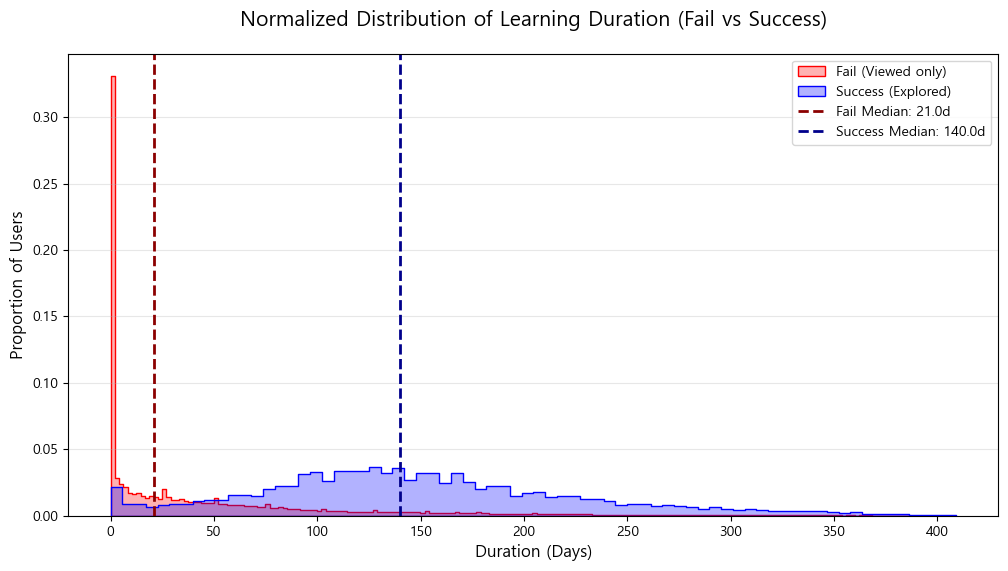

In [6]:
median_fail = df_fail_explored['duration'].median()
median_suc = df_suc_explored['duration'].median()

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# common_norm=False를 해야 각 그룹별로 100% 기준이 잡힙니다.
sns.histplot(data=df_fail_explored, x='duration', color='red', label='Fail (Viewed only)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

sns.histplot(data=df_suc_explored, x='duration', color='blue', label='Success (Explored)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

# 중앙값 표시
plt.axvline(median_fail, color='darkred', linestyle='--', linewidth=2, label=f'Fail Median: {median_fail}d')
plt.axvline(median_suc, color='darkblue', linestyle='--', linewidth=2, label=f'Success Median: {median_suc}d')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('Duration (Days)', fontsize=12)
plt.ylabel('Proportion of Users', fontsize=12) # Y축이 이제 비율(0~1)로 바뀝니다.
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Viewed의 경우, 30% 이상이 초기에 이탈하는 것을 확인할 수 있음

- 단순히 그림만 보더라도, 통계 검정까지 갈 필요 없이 전체 수강일이 길 수록 강의를 열심히 수강하는 그룹이 늘어남

- explored까지 가려면 결국 초기 이탈을 어디에서 잡을 수 있을지를 확인해야 함

In [7]:
# viewed 그룹에서 어디에서 많이 이탈하는가
df_proportion = df_fail_explored.value_counts('duration').reset_index().sort_values('duration')
df_proportion['proportion'] = df_proportion['count'] / len(df_fail_explored)
df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()
df_proportion

df_proportion['duration'] = df_proportion['duration'] + 1
start_point = pd.DataFrame({'duration':[0], 'fail_rate':[1.0]})
df_plot = pd.concat([start_point, df_proportion]).sort_values('duration').reset_index(drop = True)
df_plot.head(30)

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,1,0.763174,68153.0,0.236826
2,2,0.690528,20906.0,0.072647
3,3,0.668886,6228.0,0.021642
4,4,0.653377,4463.0,0.015509
5,5,0.640190,3795.0,0.013187
6,6,0.628233,3441.0,0.011957
7,7,0.616307,3432.0,0.011926
8,8,0.604541,3386.0,0.011766
9,9,0.594332,2938.0,0.010209


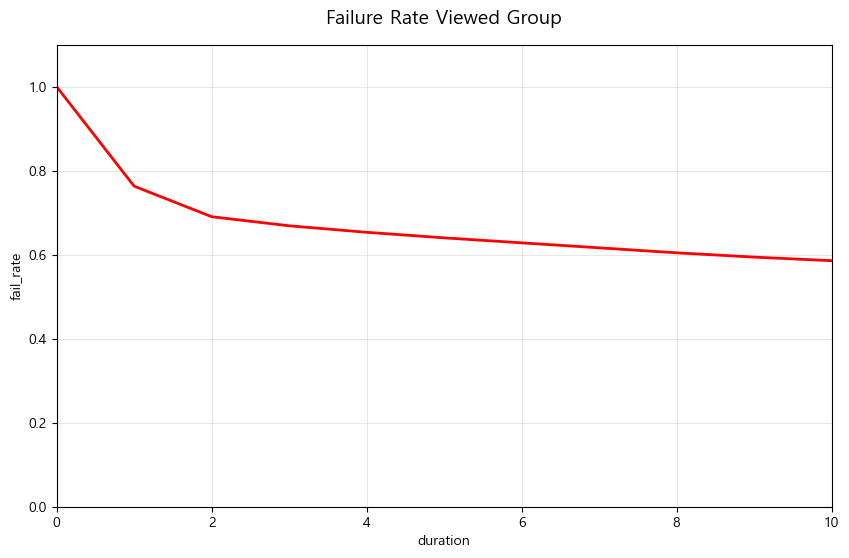

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.xlim(0, 10)
plt.ylim(0, 1.1) 
plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

초기 이탈은 유저의 행동 정보가 쌓이기 이전이기 때문에 행동 정보로는 추측할 수 없다.

따라서, 단순히 **이틀만에 32%가 빠져나가기 때문에 이 구간이 중요하다** 까지를 보일 수는 있지만, 그 이유에 대한 액션은 **추측**할 수 밖에 없다.

또한, 현재 데이터가 특정 시점에 로그 데이터를 집계한 데이터이기 때문에, explored로 진입한 유저들의 초기 활동 정보도 알 수 없다.

-> 따라서,

이것도 아마 안 될 것 같네. 2일이라는 게 너무 기간이 짧기는 하다.

In [ ]:
from sklearn.metrics import precision_recall_curve

pr_df = df_viewed[["explored", "nevents"]].dropna()

y = pr_df["explored"]
x = pr_df["nevents"]

precision, recall, thresholds = precision_recall_curve(y, x)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (F1): {best_threshold}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall: {recall[best_idx]:.4f}")

Best threshold (F1): 1274.0
Precision: 0.6858
Recall: 0.6107
